# Chapter 3, Example 3: Junction Trees for Exact Inference on a Loopy Graph

A loopy graph can be converted into a tree of overlapping clusters. The clusters must cover all factors, and neighboring clusters communicate through their intersections, called separators. If the clusters satisfy the running-intersection property, sum-product message passing on the cluster tree is exact.

This notebook demonstrates:

- triangulation of a five-cycle by fill-in edges;
- maximal cliques and separators;
- construction of a junction tree;
- exact clique-to-clique messages;
- agreement with brute-force singleton marginals.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch03":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch03").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch03"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

NODE_COLOR = "#2F6B9A"
FACTOR_COLOR = "#555555"

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## 1. A loopy pairwise model

We use five binary spins on a cycle. The original factor graph contains a loop and therefore does not admit a leaf-elimination schedule. Eliminating variables creates fill-in edges. For the order $1,2,3,4,5$, the filled graph has maximal cliques

$$
C_1=\{1,2,5\},\qquad C_2=\{2,3,5\},\qquad C_3=\{3,4,5\}.
$$

Their separators are $S_{12}=\{2,5\}$ and $S_{23}=\{3,5\}$.

<>:24: SyntaxWarning: invalid escape sequence '\{'
<>:24: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_1397/3422986559.py:24: SyntaxWarning: invalid escape sequence '\{'
  clique_labels={i:"$C_{%d}$\n$\{%s\}$"%(i+1,",".join(str(v+1) for v in cliques[i])) for i in range(3)}


Saved: figs/ch03_03_cycle_triangulation_junction_tree.pdf


Saved: figs/ch03_03_cycle_triangulation_junction_tree.png


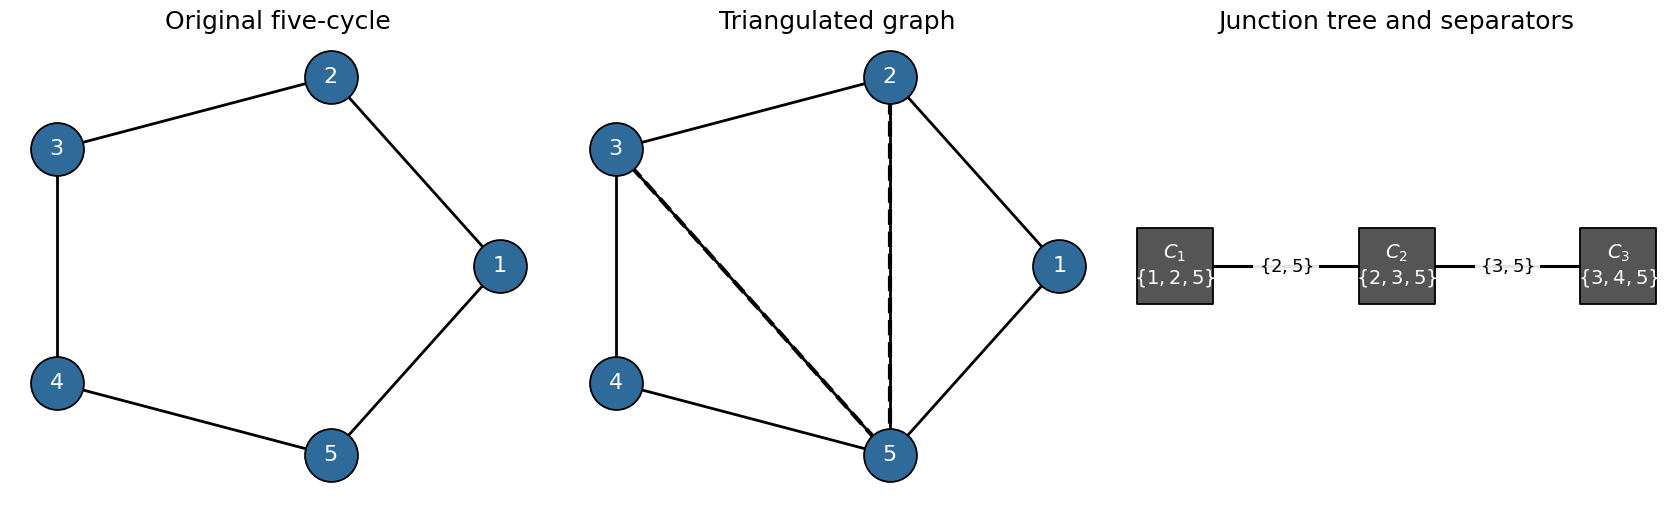

In [2]:
nodes=list(range(5))
cycle_edges=[(0,1),(1,2),(2,3),(3,4),(4,0)]
fill_edges=[(1,4),(2,4)]
triangulated_edges=cycle_edges+fill_edges
cliques=[(0,1,4),(1,2,4),(2,3,4)]
clique_tree_edges=[(0,1),(1,2)]

pos_cycle=nx.circular_layout(nx.Graph(cycle_edges),scale=1.0)
pos_clique={0:(0,0),1:(1.8,0),2:(3.6,0)}

fig,axes=plt.subplots(1,3,figsize=(17,5.3))
for ax,edges_here,title in [(axes[0],cycle_edges,"Original five-cycle"),(axes[1],triangulated_edges,"Triangulated graph")]:
    graph=nx.Graph(edges_here)
    nx.draw_networkx_edges(graph,pos_cycle,width=2.0,ax=ax)
    if title.startswith("Triangulated"):
        nx.draw_networkx_edges(graph,pos_cycle,edgelist=fill_edges,width=3.0,style="dashed",ax=ax)
    nx.draw_networkx_nodes(graph,pos_cycle,node_size=1450,node_color=NODE_COLOR,edgecolors="black",linewidths=1.3,ax=ax)
    nx.draw_networkx_labels(graph,pos_cycle,labels={i:str(i+1) for i in nodes},font_size=16,font_color="white",ax=ax)
    ax.set_title(title); ax.axis("off")

jt=nx.Graph(clique_tree_edges)
nx.draw_networkx_edges(jt,pos_clique,width=2.2,ax=axes[2])
nx.draw_networkx_nodes(jt,pos_clique,node_size=3000,node_shape="s",node_color=FACTOR_COLOR,edgecolors="black",linewidths=1.3,ax=axes[2])
clique_labels={i:"$C_{%d}$\n$\{%s\}$"%(i+1,",".join(str(v+1) for v in cliques[i])) for i in range(3)}
nx.draw_networkx_labels(jt,pos_clique,labels=clique_labels,font_size=14,font_color="white",ax=axes[2])
sep_labels={(0,1):r"$\{2,5\}$",(1,2):r"$\{3,5\}$"}
nx.draw_networkx_edge_labels(jt,pos_clique,edge_labels=sep_labels,font_size=13,rotate=False,bbox={"facecolor":"white","edgecolor":"none","alpha":0.9},ax=axes[2])
axes[2].set_title("Junction tree and separators"); axes[2].axis("off")
fig.tight_layout(); save_figure(fig,"ch03_03_cycle_triangulation_junction_tree"); plt.show()

## 2. Assigning factors to cliques

The model is

$$
w(\boldsymbol{s})=\prod_i e^{h_i s_i}\prod_{(i,j)\in E}e^{J_{ij}s_is_j}.
$$

Every original factor is assigned to one clique containing its scope. The product of assigned factors forms the initial clique potential. Fill-in edges do not introduce new physical interactions; they only enlarge the computational clusters.

In [3]:
h=np.array([0.12,-0.08,0.15,-0.05,0.09])
J={tuple(sorted(e)):v for e,v in zip(cycle_edges,[0.50,-0.38,0.44,0.36,-0.41])}
def spin(b): return 2*b-1

def factor_value(scope,bits):
    if len(scope)==1: return np.exp(h[scope[0]]*spin(bits[0]))
    i,j=scope; return np.exp(J[tuple(sorted((i,j)))]*spin(bits[0])*spin(bits[1]))

original_scopes=[(i,) for i in nodes]+cycle_edges
assignment={0:[],1:[],2:[]}
for scope in original_scopes:
    for ci,C in enumerate(cliques):
        if set(scope).issubset(C): assignment[ci].append(scope); break
print("Factor assignment to cliques:")
for ci,scopes in assignment.items(): print(ci+1,scopes)

def clique_potential(ci):
    C=cliques[ci]; values=np.ones([2]*len(C))
    for state in product((0,1),repeat=len(C)):
        val=1.0
        mapping=dict(zip(C,state))
        for scope in assignment[ci]: val*=factor_value(scope,tuple(mapping[v] for v in scope))
        values[state]=val
    return values
phi={ci:clique_potential(ci) for ci in range(3)}

Factor assignment to cliques:
1 [(0,), (1,), (4,), (0, 1), (4, 0)]
2 [(2,), (1, 2)]
3 [(3,), (2, 3), (3, 4)]


## 3. Clique-to-clique messages

For neighboring cliques $C$ and $D$ with separator $S=C\cap D$, the message is obtained by multiplying the clique potential by all incoming messages except the one from $D$, then summing over $C\setminus S$. This is ordinary sum-product message passing with cluster-valued nodes.

In [4]:
jt_neighbors={0:[1],1:[0,2],2:[1]}
messages={}

def expand_message(message,sep,C):
    shape=[2 if v in sep else 1 for v in C]
    return message.reshape(shape)

def message(ci,cj):
    if (ci,cj) in messages: return messages[(ci,cj)]
    C=cliques[ci]; sep=tuple(v for v in C if v in cliques[cj])
    value=phi[ci].copy()
    for ck in jt_neighbors[ci]:
        if ck==cj: continue
        incoming=message(ck,ci)
        sep_in=tuple(v for v in cliques[ck] if v in C)
        value*=expand_message(incoming,sep_in,C)
    axes=tuple(i for i,v in enumerate(C) if v not in sep)
    result=value.sum(axis=axes) if axes else value
    result=result/result.sum()
    messages[(ci,cj)]=result
    return result

for a,b in clique_tree_edges:
    message(a,b); message(b,a)
for key,val in messages.items(): print(f"m_{key[0]+1}->{key[1]+1} on separator {set(cliques[key[0]]) & set(cliques[key[1]])}: shape={val.shape}")

m_1->2 on separator {1, 4}: shape=(2, 2)
m_3->2 on separator {2, 4}: shape=(2, 2)
m_2->1 on separator {1, 4}: shape=(2, 2)
m_2->3 on separator {2, 4}: shape=(2, 2)


## 4. Calibrated clique beliefs and exact marginals

A calibrated clique belief is proportional to the local clique potential times all incoming messages. Marginalizing any clique belief to a variable gives the same answer as marginalizing another clique that contains that variable. This consistency is the running-intersection property in computational form.

In [5]:
def clique_belief(ci):
    C=cliques[ci]; value=phi[ci].copy()
    for ck in jt_neighbors[ci]:
        incoming=message(ck,ci)
        sep=tuple(v for v in cliques[ck] if v in C)
        value*=expand_message(incoming,sep,C)
    return value/value.sum()

beliefs={ci:clique_belief(ci) for ci in range(3)}

def singleton_from_clique(ci,v):
    C=cliques[ci]; b=beliefs[ci]
    axes=tuple(i for i,u in enumerate(C) if u!=v)
    return b.sum(axis=axes)

jt_plus=np.zeros(5)
for v in nodes:
    ci=next(i for i,C in enumerate(cliques) if v in C)
    jt_plus[v]=singleton_from_clique(ci,v)[1]

states=np.array(list(product((0,1),repeat=5)),dtype=int)
weights=[]
for bits in states:
    expo=sum(h[i]*spin(bits[i]) for i in nodes)+sum(J[tuple(sorted((i,j)))]*spin(bits[i])*spin(bits[j]) for i,j in cycle_edges)
    weights.append(np.exp(expo))
weights=np.array(weights); p=weights/weights.sum()
exact_plus=np.array([p[states[:,i]==1].sum() for i in nodes])
comparison=pd.DataFrame({"variable":[f"s{i+1}" for i in nodes],"exact P(+1)":exact_plus,"junction-tree P(+1)":jt_plus,"absolute error":abs(exact_plus-jt_plus)})
display(comparison)
assert np.max(abs(exact_plus-jt_plus))<1e-12

,variable,exact P(+1),junction-tree P(+1),absolute error
0,s1,0.511246,0.511246,0.000000e+00
1,s2,0.454991,0.454991,0.000000e+00
2,s3,0.575036,0.575036,1.110223e-16
3,s4,0.520021,0.520021,0.000000e+00
4,s5,0.535692,0.535692,1.110223e-16


Saved: figs/ch03_03_junction_tree_marginal_comparison.pdf


Saved: figs/ch03_03_junction_tree_marginal_comparison.png


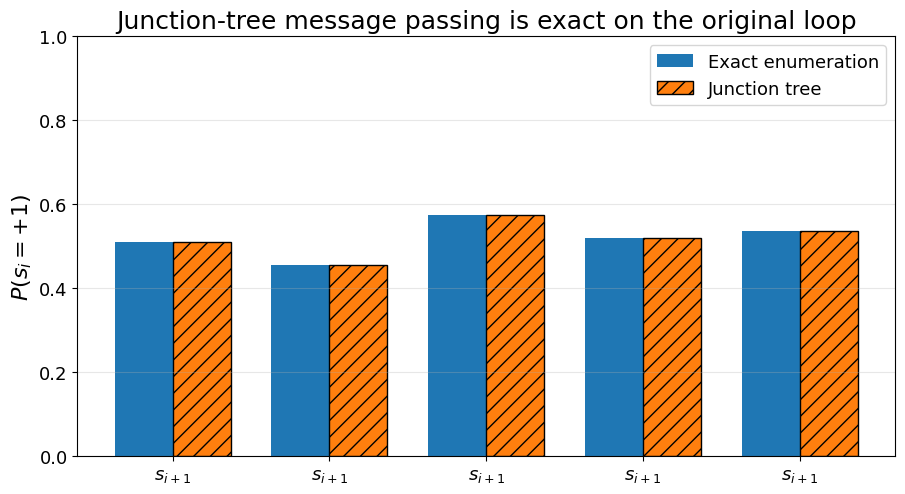

In [6]:
fig,ax=plt.subplots(figsize=(9.3,5.2))
x=np.arange(5); width=0.37
ax.bar(x-width/2,exact_plus,width,label="Exact enumeration")
ax.bar(x+width/2,jt_plus,width,label="Junction tree",hatch="//",edgecolor="black")
ax.set_xticks(x,[rf"$s_{{i+1}}$" for i in range(5)])
ax.set_ylim(0,1); ax.set_ylabel(r"$P(s_i=+1)$")
ax.set_title("Junction-tree message passing is exact on the original loop")
ax.grid(axis="y",alpha=0.3); ax.legend()
fig.tight_layout(); save_figure(fig,"ch03_03_junction_tree_marginal_comparison"); plt.show()

## 5. Complexity

The largest clique contains three binary variables, so its table has $2^3=8$ entries. In general, the cost is exponential in the largest clique size, or equivalently in treewidth plus one. Junction trees do not remove exponential complexity; they expose precisely where it resides.

## Exercises

1. Change the elimination order and construct the corresponding fill-in edges and cliques.
2. Verify separator consistency by marginalizing the two adjacent clique beliefs to their shared separator.
3. Add a chord to the original graph and determine whether the required junction-tree width decreases.
4. Replace one pairwise factor by a hard constraint and verify that the algorithm remains exact.
5. Compare the junction-tree tables with tensors produced by variable elimination in the first notebook.